# **Helper Functions**

## Importing Dependencies

In [11]:
import time
import numpy as np
import os
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torchsummary

import seaborn
from sklearn.metrics import confusion_matrix

## Constants

In [12]:
SEED = 42
BATCH_SIZE = 128
CLASS_LABELS = ["airplaine", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

## Preprocessing Images and Creating Split

In [13]:
def set_seed(seed: int = SEED) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def get_split(batch: int = BATCH_SIZE, workers: int=2, path: str = "./data"):
    """
    Returns a CIFAR10 train/val/test split as required using a set seed of 42 to ensure a consistent split of images throughout each run
    """

    # Required to normalize the images
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    # Defining the two transform sets that will be used on the dataset
    tf_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    tf_valTest = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    # Bifurcating transforms for each split
    ds_aug = torchvision.datasets.CIFAR10(path, train=True, download=True, transform=tf_train)
    ds_norm = torchvision.datasets.CIFAR10(path, train=True, download=False, transform=tf_valTest)
    ds_test = torchvision.datasets.CIFAR10(path, train=False, download=False, transform=tf_valTest)

    # Creating the split
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(50_000)
    tr_id = perm[:45_000] # Training Split = 45k images
    val_id = perm[45_000:] # Valudation Split = 5k images

    kw = dict(num_workers=workers, pin_memory=torch.cuda.is_available())

    train_split = DataLoader(Subset(ds_aug, tr_id), batch_size=batch, shuffle=True, **kw)
    val_split = DataLoader(Subset(ds_norm, val_id), batch_size=batch, shuffle=False, **kw)
    test_split = DataLoader(ds_test, batch_size=batch, shuffle=False, **kw)

    print(f"Data   : {len(tr_id):,} train | {len(val_id):,} val | {len(ds_test):,} test")

    return train_split, val_split, test_split

## Parameter Counting

In [14]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_hyperparams(**kwargs) -> None:
    print("\n" + "─" * 50)
    for k, v in kwargs.items():
        print(f"  {k:<18}: {v}")
    print("─" * 50)

## Training-Related Functions

In [15]:
def _train_epoch(model, loader, crit, opt, device):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = crit(model(x), y)
        loss.backward()
        opt.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, crit, device):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    all_pred, all_true = [], []
    for x, y in loader:
        x, y    = x.to(device), y.to(device)
        out     = model(x)
        loss_sum += crit(out, y).item() * x.size(0)
        pred    = out.argmax(1)
        correct += pred.eq(y).sum().item()
        n       += y.size(0)
        all_pred.extend(pred.cpu().numpy())
        all_true.extend(y.cpu().numpy())
    return (loss_sum / n,
            100.0 * correct / n,
            np.array(all_pred),
            np.array(all_true))

def train_model(model, train_split, val_split,
                num_epochs, optimizer, scheduler=None, device=None):
    """
    Full training loop.  Returns a history dict with keys:
      train_loss, val_loss, val_acc, epoch_time
    """
    if device is None:
        device = "cuda:0"
    model.to(device)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}

    for ep in range(num_epochs):
        t0      = time.time()
        tr_loss = _train_epoch(model, train_split, crit, optimizer, device)
        vl_loss, vl_acc, _, _ = _eval_epoch(model, val_split, crit, device)
        dt      = time.time() - t0
        if scheduler:
            scheduler.step()

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(vl_loss)
        hist["val_acc"].append(vl_acc)
        hist["epoch_time"].append(dt)

        print(f"  Ep {ep+1:3d}/{num_epochs}  "
              f"TrLoss {tr_loss:.4f}  VlLoss {vl_loss:.4f}  "
              f"VlAcc {vl_acc:6.2f}%  ({dt:.1f}s)")

    return hist


@torch.no_grad()
def evaluate(model, loader, device):
    """Final evaluation on any loader — returns (loss, acc, preds, labels)."""
    model.to(device)
    return _eval_epoch(model, loader, nn.CrossEntropyLoss(), device)

## Graphing Functions

In [16]:
def save_training_curves(histories: dict, title: str, path: str) -> None:
    """
    histories: {label: history_dict}
    Produces a 3-panel figure: Training Loss | Validation Loss | Validation Accuracy
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    panels = [("train_loss", "Training Loss",     "Loss"),
              ("val_loss",   "Validation Loss",   "Loss"),
              ("val_acc",    "Validation Accuracy","Accuracy (%)")]

    for lbl, h in histories.items():
        for ax, (key, ttl, yl) in zip(axes, panels):
            ax.plot(h[key], label=lbl, linewidth=1.5)

    for ax, (_, ttl, yl) in zip(axes, panels):
        ax.set(title=ttl, xlabel="Epoch", ylabel=yl)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")

def _cm(true, pred):
    return confusion_matrix(true, pred)

def save_confusion_matrix(true_labels, pred_labels, title: str, path: str) -> None:
    cm = _cm(true_labels, pred_labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    seaborn.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
                    linewidths=0.4, ax=ax)
    
    ax.set(title=title, xlabel="Predicted Label", ylabel="True Label")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")

def save_filter_visualization(model: nn.Module, title: str, path: str) -> None:
    """
    Visualises the learned filters of the first Conv2d layer.
    Filters with 3 input channels are shown as RGB patches;
    single-channel filters are shown with a 'viridis' colourmap.
    """
    first_conv = next(m for m in model.modules() if isinstance(m, nn.Conv2d))
    W = first_conv.weight.detach().cpu()          # [C_out, C_in, H, W]
    n = min(W.shape[0], 64)
    ncols = 8
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.5, nrows * 1.5))
    axes = np.array(axes).reshape(nrows, ncols)

    for i in range(nrows * ncols):
        ax = axes[i // ncols, i % ncols]
        if i < n:
            w = W[i]                              # [C_in, H, W]
            w = w - w.min()
            w = w / (w.max() + 1e-8)             # normalise to [0, 1]
            if w.shape[0] == 3:
                ax.imshow(w.permute(1, 2, 0).numpy())
            else:
                ax.imshow(w[0].numpy(), cmap="viridis")
        ax.axis("off")

    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")

# For the Questions 2 and 3
def save_results(out_dir: str, data: dict) -> None:
    os.makedirs(out_dir, exist_ok=True)
    p = os.path.join(out_dir, "results.json")
    with open(p, "w") as f:
        json.dump(data, f, indent=2)
    print(f"  Saved → {p}")


# **Question 1**

## Set-Up

In [17]:
# Configuring hyperparameters
learning_rate = 1e-3
weight_decay = 1e-4
NUM_EPOCHS = 40

ORIGINAL_PARAMS = 61_100_840

out_path = "output/q1"
os.makedirs(out_path, exist_ok=True)

class CIFAR10AlexNet(nn.Module):
    def __init__(self, num_classes: int=10, dropout_rate: float=0.0):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3,   32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(32,  64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Block 4
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Block 5
            nn.Conv2d(128,  64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    # Initialising wieghts
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
# Optimizer and Scheduling helper function
def make_opt_sched(model):
    opt   = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    return opt, sched

## **Part 1A**

In [18]:
def run_part_a(train_split, val_split, test_split, device):
    print("\n" + "=" * 60)
    print("Question 1  Part A — Modified AlexNet (no dropout)")
    print("=" * 60)

    # Architecture summary 
    set_seed(SEED)
    model  = CIFAR10AlexNet(dropout_rate=0.0)
    params = count_parameters(model)

    print(f"\nModified AlexNet params : {params:>12,}")
    print(f"Original AlexNet params : {ORIGINAL_PARAMS:>12,}")
    print(f"Reduction               : {100*(1 - params/ORIGINAL_PARAMS):.1f}%")

    # Printing Used Parameters
    print("\nLayer-wise breakdown:")
    for name, p in model.named_parameters():
        print(f"  {name:<40} {p.numel():>10,}")

    # Printing Hyper Parameters
    print_hyperparams(
        Problem="1A",
        Model="CIFAR10AlexNet (p=0.0)",
        Epochs=NUM_EPOCHS,
        BatchSize=BATCH_SIZE,
        Optimizer=f"Adam lr={learning_rate} wd={weight_decay}",
        Scheduler=f"CosineAnnealingLR T_max={NUM_EPOCHS}",
        Device=device,
        Seed=SEED,
    )

    opt, sched = make_opt_sched(model)
    history = train_model(model, train_split, val_split,
                          NUM_EPOCHS, opt, sched, device)

    # Final test evaluation
    _, test_acc, preds, labels = evaluate(model, test_split, device)
    print(f"\nFinal Test Accuracy : {test_acc:.2f}%")

    # Calling Graph Functions
    save_training_curves(
        {"Baseline (no dropout)": history},
        "CIFAR10 AlexNet — Training Curves (Part A)",
        f"{out_path}/1a_training_curves.png",
    )
    save_confusion_matrix(
        labels, preds,
        f"CIFAR10 AlexNet — Confusion Matrix  (Test Acc: {test_acc:.2f}%)",
        f"{out_path}/1a_confusion_matrix.png",
    )
    
    # Filter visualisation
    save_filter_visualization(
        model,
        "CIFAR10 AlexNet — First Conv Layer Filters  (32 filters, 3×3, RGB)",
        f"{out_path}/1a_filters.png",
    )

    return model, history, test_acc, params

## **Part 1B**

In [19]:
def run_part_b(baseline_history, baseline_test_acc,
               train_split, val_split, test_split, device):
    print("\n" + "=" * 60)
    print("Question 1  Part B — Dropout Regularisation")
    print("=" * 60)

    results     = {"p=0.0 (baseline)": baseline_test_acc}
    histories   = {"Baseline (p=0.0)": baseline_history}

    for p in [0.3, 0.5]:
        print(f"\nDropout rate p = {p}")
        set_seed(SEED)
        model = CIFAR10AlexNet(dropout_rate=p)
        opt, sched = make_opt_sched(model)
        history = train_model(model, train_split, val_split,
                              NUM_EPOCHS, opt, sched, device)

        _, test_acc, preds, labels = evaluate(model, test_split, device)
        print(f"Test Accuracy (p={p}): {test_acc:.2f}%")

        tag = f"Dropout p={p}"
        histories[tag] = history
        results[f"p={p}"]  = test_acc

        save_confusion_matrix(
            labels, preds,
            f"CIFAR10 AlexNet (dropout p={p}) — Confusion Matrix  (Test Acc: {test_acc:.2f}%)",
            f"{out_path}/1b_cm_p{'03' if p == 0.3 else '05'}.png",
        )

    # Comparison curves
    save_training_curves(
        histories,
        "CIFAR10 AlexNet — Dropout Comparison (Part B)",
        f"{out_path}/1b_dropout_comparison.png",
    )


    # Train and Val gap analysis
    print("\nTrain/Val Gap Analysis")
    print(f"{'Variant':<22} {'Final TrLoss':>13} {'Final VlLoss':>13} "
          f"{'Gap (Tr-Vl)':>12} {'VlAcc':>8}")
    print("─" * 72)
    for lbl, h in histories.items():
        tr = h["train_loss"][-1]
        vl = h["val_loss"][-1]
        ac = h["val_acc"][-1]
        print(f"  {lbl:<20} {tr:>13.4f} {vl:>13.4f} {tr - vl:>12.4f} {ac:>7.2f}%")

    return results

# Main Function

Question 1: ALEXNET ON CIFAR-10
Random seed : 42
Using device: cuda:0
Data   : 45,000 train | 5,000 val | 10,000 test

Question 1  Part A — Modified AlexNet (no dropout)

Modified AlexNet params :      973,322
Original AlexNet params :   61,100,840
Reduction               : 98.4%

Layer-wise breakdown:
  features.0.weight                               864
  features.0.bias                                  32
  features.3.weight                            18,432
  features.3.bias                                  64
  features.6.weight                            73,728
  features.6.bias                                 128
  features.8.weight                           147,456
  features.8.bias                                 128
  features.10.weight                           73,728
  features.10.bias                                 64
  classifier.0.weight                         524,288
  classifier.0.bias                               512
  classifier.3.weight                         13

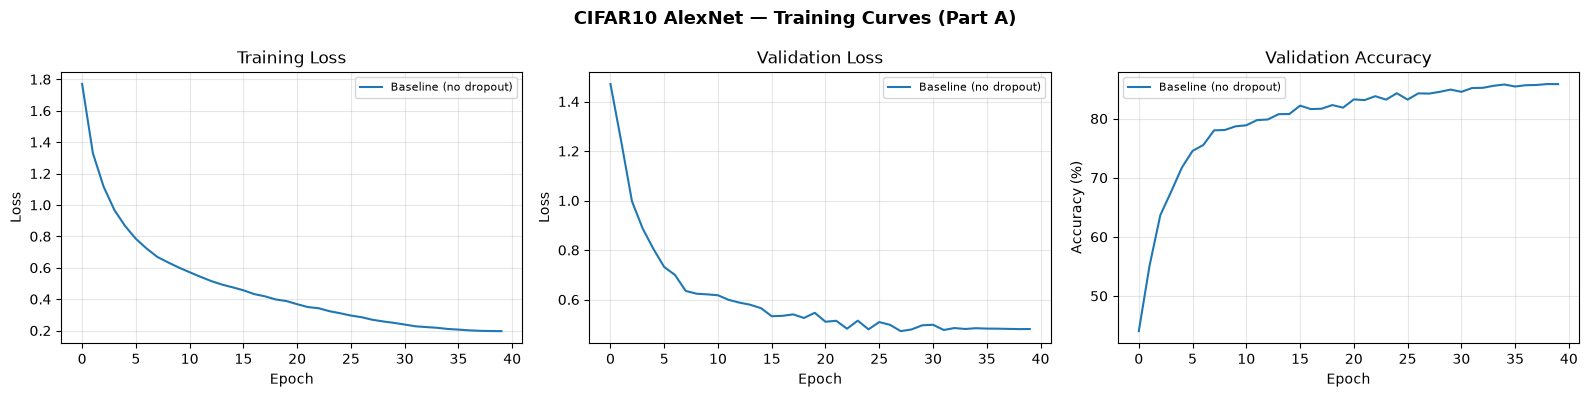

  Saved → output/q1/1a_training_curves.png


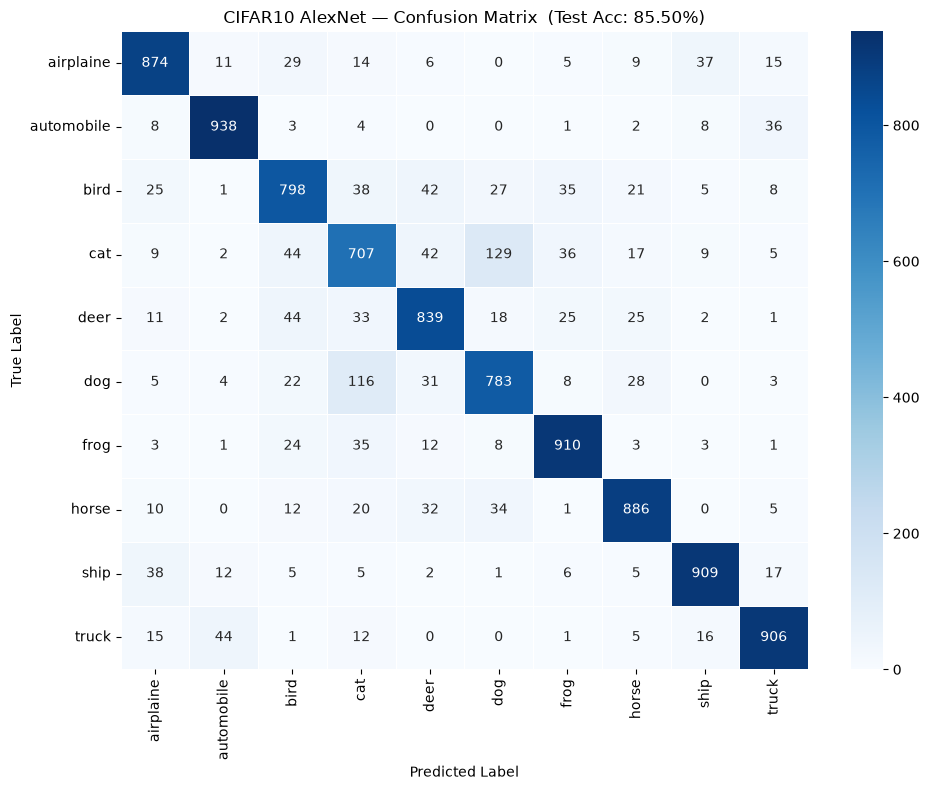

  Saved → output/q1/1a_confusion_matrix.png


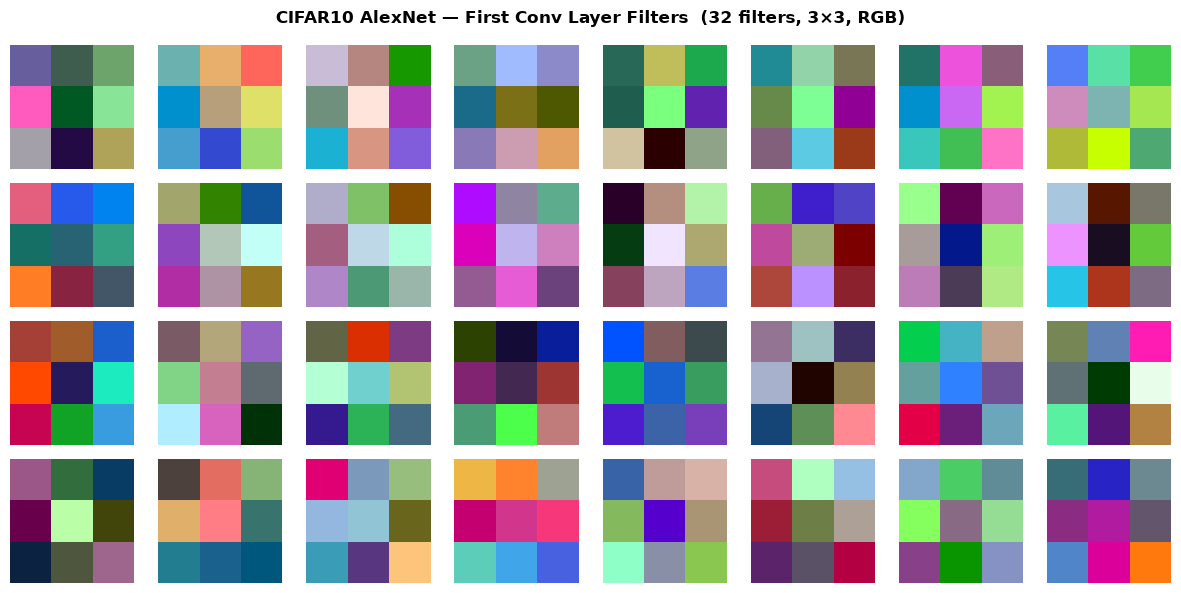

  Saved → output/q1/1a_filters.png

Question 1  Part B — Dropout Regularisation

Dropout rate p = 0.3
  Ep   1/40  TrLoss 1.8141  VlLoss 1.4818  VlAcc  45.58%  (3.9s)
  Ep   2/40  TrLoss 1.3777  VlLoss 1.1708  VlAcc  57.84%  (3.8s)
  Ep   3/40  TrLoss 1.1826  VlLoss 1.0766  VlAcc  59.68%  (3.8s)
  Ep   4/40  TrLoss 1.0351  VlLoss 0.9489  VlAcc  65.60%  (3.8s)
  Ep   5/40  TrLoss 0.9348  VlLoss 0.8309  VlAcc  70.30%  (3.7s)
  Ep   6/40  TrLoss 0.8518  VlLoss 0.7683  VlAcc  72.64%  (3.7s)
  Ep   7/40  TrLoss 0.8026  VlLoss 0.7463  VlAcc  73.78%  (3.6s)
  Ep   8/40  TrLoss 0.7431  VlLoss 0.7008  VlAcc  75.34%  (3.7s)
  Ep   9/40  TrLoss 0.7044  VlLoss 0.7270  VlAcc  74.34%  (3.7s)
  Ep  10/40  TrLoss 0.6771  VlLoss 0.6600  VlAcc  77.64%  (3.7s)
  Ep  11/40  TrLoss 0.6305  VlLoss 0.6392  VlAcc  78.36%  (3.7s)
  Ep  12/40  TrLoss 0.6080  VlLoss 0.6161  VlAcc  78.78%  (3.7s)
  Ep  13/40  TrLoss 0.5740  VlLoss 0.6465  VlAcc  77.88%  (3.7s)
  Ep  14/40  TrLoss 0.5619  VlLoss 0.5952  VlAcc  80.

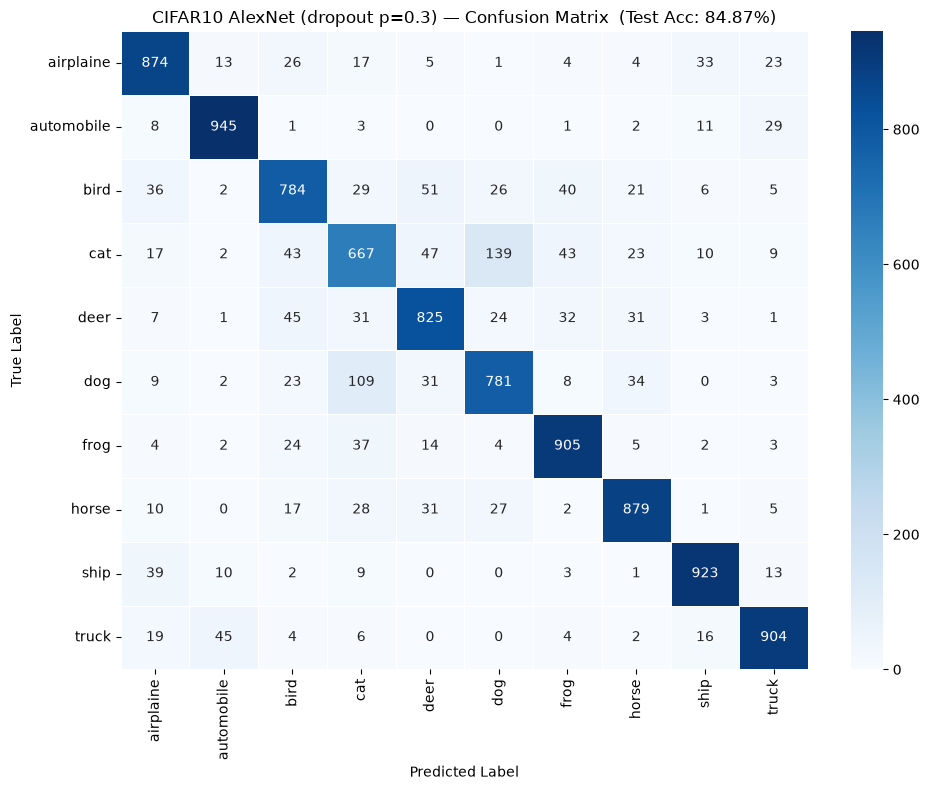

  Saved → output/q1/1b_cm_p03.png

Dropout rate p = 0.5
  Ep   1/40  TrLoss 1.8633  VlLoss 1.5141  VlAcc  42.62%  (3.7s)
  Ep   2/40  TrLoss 1.4336  VlLoss 1.1842  VlAcc  56.42%  (3.6s)
  Ep   3/40  TrLoss 1.2166  VlLoss 1.1377  VlAcc  57.10%  (3.7s)
  Ep   4/40  TrLoss 1.0663  VlLoss 0.9302  VlAcc  66.52%  (3.6s)
  Ep   5/40  TrLoss 0.9600  VlLoss 0.8494  VlAcc  69.76%  (3.7s)
  Ep   6/40  TrLoss 0.8848  VlLoss 0.7803  VlAcc  72.20%  (3.8s)
  Ep   7/40  TrLoss 0.8292  VlLoss 0.7519  VlAcc  73.22%  (3.6s)
  Ep   8/40  TrLoss 0.7690  VlLoss 0.7153  VlAcc  75.00%  (3.7s)
  Ep   9/40  TrLoss 0.7408  VlLoss 0.7262  VlAcc  75.04%  (3.7s)
  Ep  10/40  TrLoss 0.6910  VlLoss 0.6585  VlAcc  76.92%  (3.7s)
  Ep  11/40  TrLoss 0.6596  VlLoss 0.6521  VlAcc  77.46%  (3.7s)
  Ep  12/40  TrLoss 0.6371  VlLoss 0.6373  VlAcc  78.40%  (3.6s)
  Ep  13/40  TrLoss 0.6105  VlLoss 0.6407  VlAcc  77.54%  (3.7s)
  Ep  14/40  TrLoss 0.5845  VlLoss 0.5932  VlAcc  80.06%  (3.8s)
  Ep  15/40  TrLoss 0.5613  VlLoss

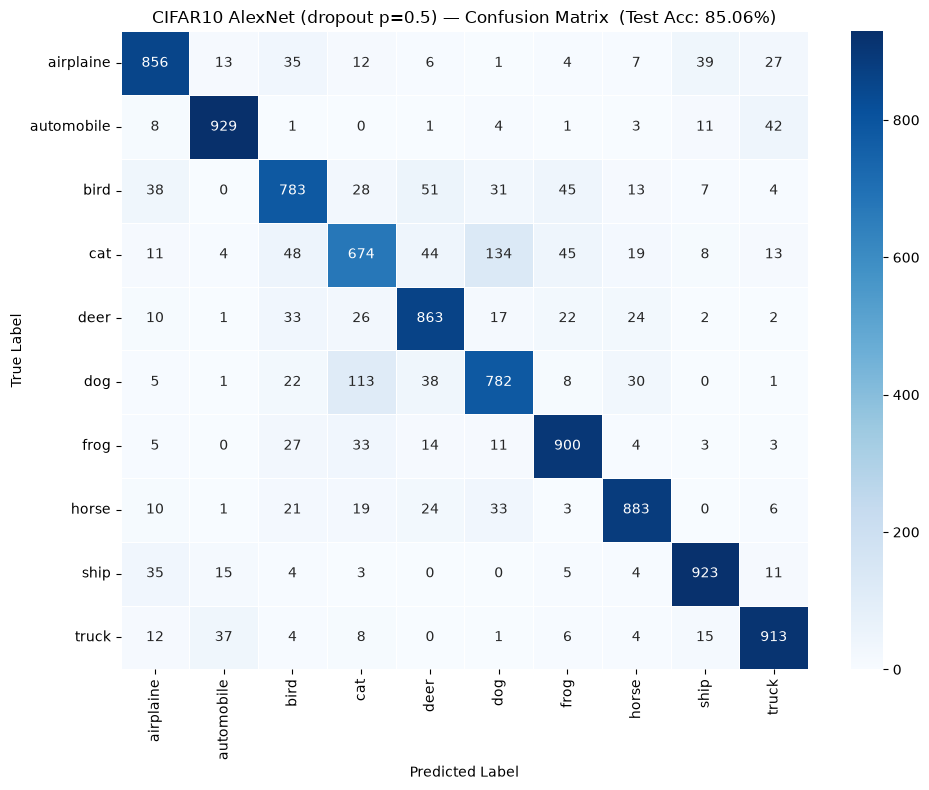

  Saved → output/q1/1b_cm_p05.png


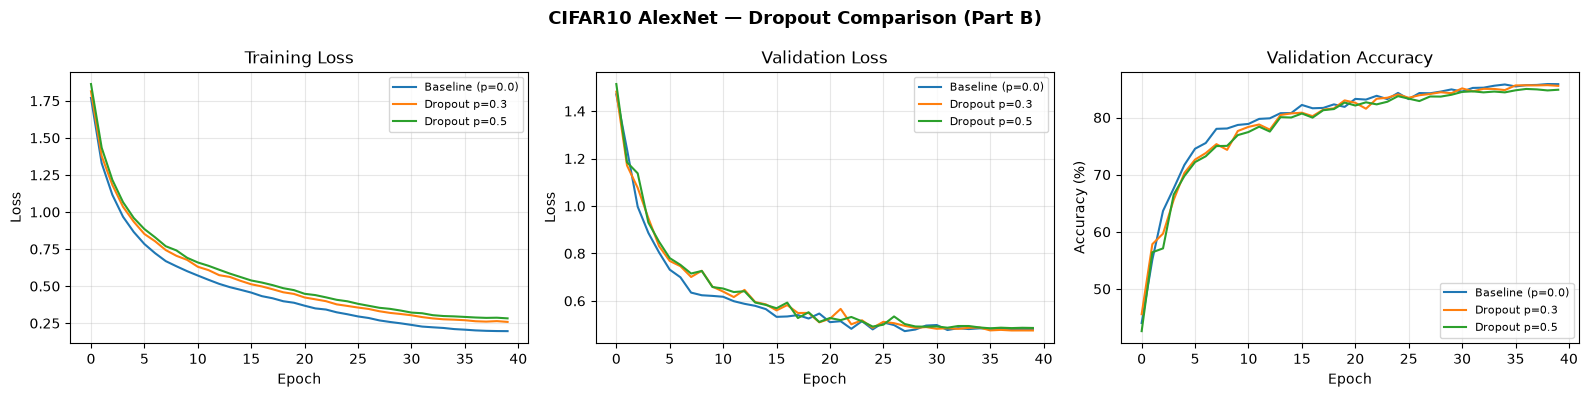

  Saved → output/q1/1b_dropout_comparison.png

Train/Val Gap Analysis
Variant                 Final TrLoss  Final VlLoss  Gap (Tr-Vl)    VlAcc
────────────────────────────────────────────────────────────────────────
  Baseline (p=0.0)            0.1964        0.4811      -0.2847   85.84%
  Dropout p=0.3               0.2587        0.4753      -0.2167   85.54%
  Dropout p=0.5               0.2825        0.4860      -0.2034   84.86%

PROBLEM 1  Summary
  p=0.0 (baseline)      : 85.50% ◄ best
  p=0.3                 : 84.87%
  p=0.5                 : 85.06%
  Saved → output/q1/results.json


In [20]:
def main():
    print(f"{'='*60}")
    print(f"Question 1: ALEXNET ON CIFAR-10")
    print(f"Random seed : {SEED}")
    print(f"{'='*60}")

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    
    set_seed(SEED)
    train_split, val_split, test_split = get_split(BATCH_SIZE)

    # Part A — baseline
    model_a, hist_a, acc_a, params_a = run_part_a(
        train_split, val_split, test_split, device
    )

    # Part B — dropout
    dropout_results = run_part_b(
        hist_a, acc_a,
        train_split, val_split, test_split, device
    )

    # Summary
    print("\n" + "=" * 60)
    print("PROBLEM 1  Summary")
    print("=" * 60)
    best_acc = max(dropout_results.values())
    best_var = max(dropout_results, key=dropout_results.get)
    for variant, acc in dropout_results.items():
        marker = " ◄ best" if acc == best_acc else ""
        print(f"  {variant:<22}: {acc:.2f}%{marker}")

    # Saving Results for Questions 2 and 3
    save_results(out_path, {
        "seed"           : SEED,
        "epochs"         : NUM_EPOCHS,
        "batch_size"     : BATCH_SIZE,
        "lr"             : learning_rate,
        "weight_decay"   : weight_decay,
        "optimizer"      : "Adam",
        "scheduler"      : "CosineAnnealingLR",
        "params"         : params_a,
        "original_params": ORIGINAL_PARAMS,
        "baseline_acc"   : acc_a,
        "dropout_03_acc" : dropout_results.get("p=0.3", 0.0),
        "dropout_05_acc" : dropout_results.get("p=0.5", 0.0),
        "best_acc"       : best_acc,
        "best_variant"   : best_var,
    })

    return {
        "model"          : model_a,
        "history"        : hist_a,
        "baseline_acc"   : acc_a,
        "params"         : params_a,
        "dropout_results": dropout_results,
        "best_acc"       : best_acc,
    }


if __name__ == "__main__":
    main()